**Install dependencies** ⚓

In [ ]:
!pip install qiskit qiskit-aer
!pip install pylatexenc

**Entanglement Swapping Code**⭐


  ENTANGLEMENT SWAPPING
  Start:  Bell pair A-B   and   Bell pair C-D
  Do:     Bell measurement on the inner qubits B and C
  Claim:  A and D end up entangled, having never interacted

  PART 1 - MEASUREMENT STATISTICS  (witness, not proof)

  Outer qubits A and D, measured in the Z basis
   BSM (B,C)    A    D    shots    agree
  ----------------------------------------------------
          00    0    0      119      yes
          00    1    1      123      yes
          01    0    0      119      yes
          01    1    1      108      yes
          10    0    0      152      yes
          10    1    1      124      yes
          11    0    0      137      yes
          11    1    1      142      yes
  ----------------------------------------------------
  A and D agreed on 1024/1024 shots (100.0%)

  Outer qubits A and D, measured in the X basis
   BSM (B,C)    A    D    shots    agree
  ----------------------------------------------------
          00    0    0      138      yes

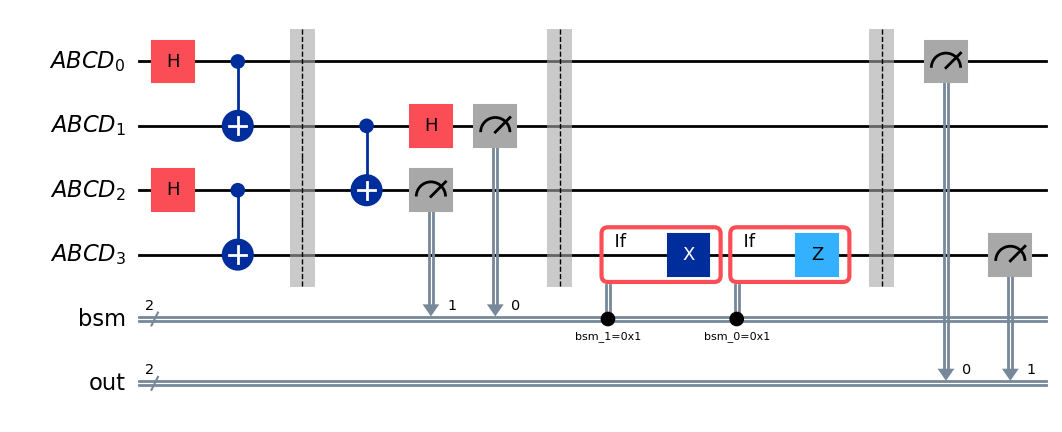

In [ ]:
%matplotlib inline

import numpy as np
from IPython.display import display
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, partial_trace, concurrence
from qiskit_aer import AerSimulator

LINE = "=" * 60
BAR = "-" * 60


# ---------------------------------------------------------------- build

# no classical register here, so Part 2 can read the statevector
def two_pairs():
    """A(0)-B(1) and C(2)-D(3) as two independent Bell pairs."""
    qc = QuantumCircuit(4)
    qc.h(0); qc.cx(0, 1)
    qc.h(2); qc.cx(2, 3)
    return qc


def swap_circuit(basis="Z", labeled=False):
    """Full protocol: pairs, BSM on inner qubits, corrections, readout."""
    q = QuantumRegister(4, "ABCD" if labeled else "q")
    bsm = ClassicalRegister(2, "bsm")
    out = ClassicalRegister(2, "out")
    qc = QuantumCircuit(q, bsm, out)

    qc.h(0); qc.cx(0, 1)          # pair A-B
    qc.h(2); qc.cx(2, 3)          # pair C-D
    qc.barrier()

    qc.cx(1, 2); qc.h(1)          # Entangle B & C, then rotate Bell basis to computational
                                  # basis so B can be differentiated for calculation
    qc.measure(2, bsm[0])         # -> X correction bit
    qc.measure(1, bsm[1])         # -> Z correction bit
    qc.barrier()

    with qc.if_test((bsm[0], 1)): qc.x(3)
    with qc.if_test((bsm[1], 1)): qc.z(3)
    qc.barrier()

    if basis == "X":
        qc.h(0); qc.h(3)
    qc.measure(0, out[0])
    qc.measure(3, out[1])
    return qc


# ------------------------------------------- part 1: counts (a witness)

def correlations(basis, shots=1024):
    counts = AerSimulator().run(swap_circuit(basis), shots=shots).result().get_counts()

    print(f"\n  Outer qubits A and D, measured in the {basis} basis")
    print(f"  {'BSM (B,C)':>10} {'A':>4} {'D':>4} {'shots':>8}  {'agree':>7}")
    print("  " + BAR[:52])

    agreed, rows = 0, []
    for key, n in counts.items():
        out_bits, bsm_bits = key.split()
        a, d = out_bits[1], out_bits[0]      # Qiskit prints little-endian
        ok = a == d
        agreed += n if ok else 0
        rows.append((bsm_bits, a, d, n, ok))

    for bsm_bits, a, d, n, ok in sorted(rows):
        print(f"  {bsm_bits:>10} {a:>4} {d:>4} {n:>8}  {'yes' if ok else 'NO':>7}")

    pct = 100 * agreed / shots
    print("  " + BAR[:52])
    print(f"  A and D agreed on {agreed}/{shots} shots ({pct:.1f}%)")
    return pct


# ---------------------------------------- part 2: the state (the proof)

def rho_before():
    """A-D reduced state before any Bell measurement."""
    return partial_trace(Statevector(two_pairs()), [1, 2]).data


def rho_after():
    """A-D state after BSM on B,C, postselected on outcome 00."""
    qc = two_pairs()
    qc.cx(1, 2); qc.h(1)
    vec = np.asarray(Statevector(qc)).reshape([2, 2, 2, 2])  # q3,q2,q1,q0
    sub = vec[:, 0, 0, :].flatten()                          # project C=0, B=0
    sub = sub / np.linalg.norm(sub)
    return np.outer(sub, sub.conj())


def show_matrix(rho, label):
    print(f"\n  {label}")
    print("        |00>   |01>   |10>   |11>")
    for name, row in zip(["|00>", "|01>", "|10>", "|11>"], rho):
        print(f"  {name}  " + "  ".join(f"{v.real:5.2f}" for v in row))


# ------------------------------------------------------------------ run

print(LINE)
print("  ENTANGLEMENT SWAPPING")
print(LINE)
print("  Start:  Bell pair A-B   and   Bell pair C-D")
print("  Do:     Bell measurement on the inner qubits B and C")
print("  Claim:  A and D end up entangled, having never interacted")

print(f"\n{LINE}")
print("  PART 1 - MEASUREMENT STATISTICS  (witness, not proof)")
print(LINE)

z = correlations("Z")
x = correlations("X")

print(f"\n  Z basis: {z:.1f}%   X basis: {x:.1f}%")
print("  Correlation in two mutually unbiased bases rules out a shared")
print("  classical random bit, which could only match in one. But counts")
print("  alone cannot distinguish an entangled state from a classical")
print("  mixture of |00> and |11>. For that, look at the state itself.")

print(f"\n{LINE}")
print("  PART 2 - STATE INSPECTION  (the proof)")
print(LINE)

before, after = rho_before(), rho_after()
c_before, c_after = concurrence(before), concurrence(after)

show_matrix(before, "A-D density matrix BEFORE the Bell measurement:")
print(f"\n  concurrence = {c_before:.4f}   -> separable, not entangled")

show_matrix(after, "A-D density matrix AFTER the Bell measurement:")
print(f"\n  concurrence = {c_after:.4f}   -> maximally entangled")

print(f"\n{BAR}")
print("  Concurrence: 0 = separable, 1 = maximally entangled.")
print(f"  The Bell measurement took A-D from {c_before:.2f} to {c_after:.2f}.")
print("  Nothing else in the circuit touched A or D, so the swap is what")
print("  created the entanglement.")
print("\n  The off-diagonal 0.50 terms are coherence. A classical mixture")
print("  of |00> and |11> would have zeros there and would still pass")
print("  Part 1's Z-basis test. That is correlated vs entangled.")
print(BAR)


# ---------------------------------------------------- part 3: the circuit

print(f"\n{LINE}")
print("  PART 3 - CIRCUIT")
print(LINE)
print("  1. build pair A-B and pair C-D")
print("  2. Bell measurement on inner qubits B and C")
print("  3. Pauli corrections on D, conditioned on that result")
print("  4. measure outer qubits A and D\n")

diagram = swap_circuit("Z", labeled=True)

try:
    display(diagram.draw(output="mpl", style="iqp", fold=28))
except Exception as err:
    print(f"  (mpl unavailable: {err})")
    print(diagram.draw(output="text", fold=100))

circuit diagram by itself

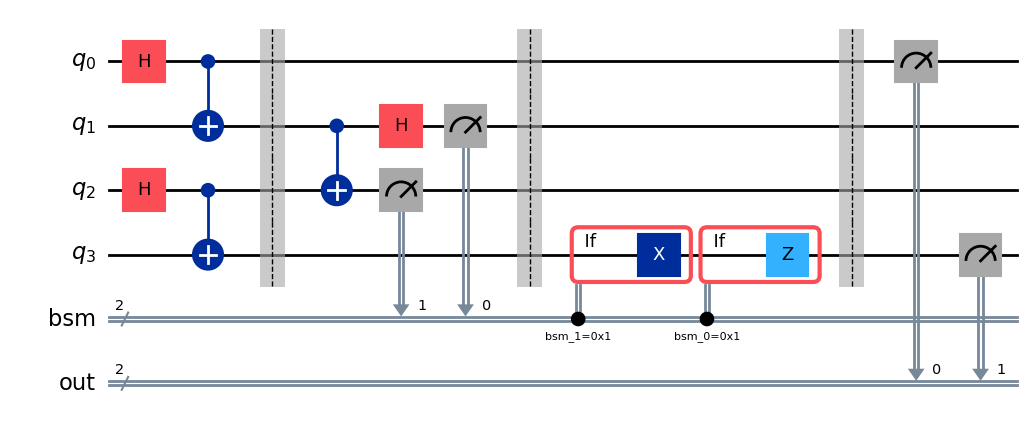

In [ ]:
!pip install pylatexenc -q

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

q   = QuantumRegister(4, "q")
bsm = ClassicalRegister(2, "bsm")
out = ClassicalRegister(2, "out")
qc  = QuantumCircuit(q, bsm, out)

qc.h(0); qc.cx(0, 1)
qc.h(2); qc.cx(2, 3)
qc.barrier()

qc.cx(1, 2); qc.h(1)
qc.measure(1, bsm[0])
qc.measure(2, bsm[1])
qc.barrier()

with qc.if_test((bsm[1], 1)): qc.x(3)
with qc.if_test((bsm[0], 1)): qc.z(3)
qc.barrier()

qc.measure(0, out[0])
qc.measure(3, out[1])

qc.draw(output="mpl")